In [ ]:
!sudo apt-get update
!sudo apt-get install -y lkh
!sudo apt-get install -y libgmp-dev
!pip install gurobipy python-tsp networkx lkh
!pip install python-tsp
!pip install pyconcorde
#!pip install 'pyconcorde @ git+https://github.com/jvkersch/pyconcorde'

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

In [ ]:
# @title Setup
from google.colab import drive
from google.colab import userdata
import numpy as np
import gurobipy as gp
from gurobipy import GRB
from dataclasses import dataclass
from typing import List, Tuple, Optional, Callable
import time
from python_tsp.exact import solve_tsp_dynamic_programming


drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# @title Basic Definitions
@dataclass
class TSPInstance:
    """Represents a TSP problem instance"""
    name: str
    n_cities: int
    distances: np.ndarray  # n x n distance matrix

    @classmethod
    def from_coordinates(cls, name: str, coords: np.ndarray) -> 'TSPInstance':
        """Create TSP instance from city coordinates"""
        n = len(coords)
        dist = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                dist[i, j] = np.linalg.norm(coords[i] - coords[j])
        return cls(name, n, dist)

    @classmethod
    def from_tsplib(cls, filepath: str) -> 'TSPInstance':
        """Load TSP instance from TSPLIB format file"""
        coords = []
        reading_coords = False
        name = filepath.split('/')[-1].split('.')[0]

        with open(filepath, 'r') as f:
            for line in f:
                line = line.strip()
                if line.startswith('NODE_COORD_SECTION'): # Only euclidian distances implemented for now
                    reading_coords = True
                    continue
                if line == 'EOF' or not line:
                    break
                if reading_coords:
                    parts = line.split()
                    coords.append([float(parts[1]), float(parts[2])])

        if len(coords) > 0:
            return cls.from_coordinates(name, np.array(coords))
        else:
            return None

@dataclass
class SolverConfig:
    """Configuration for Gurobi solver"""
    time_limit: Optional[float] = None  # seconds
    mip_gap: float = 0.01  # 1% gap
    threads: Optional[int] = None
    verbose: bool = True
    callback: Callable = None
    use_mtz: bool = False

    def apply_to_model(self, model: gp.Model):
        """Apply configuration to Gurobi model"""
        if self.time_limit:
            model.Params.TimeLimit = self.time_limit
        model.Params.MIPGap = self.mip_gap
        if self.threads:
            model.Params.Threads = self.threads
        model.Params.OutputFlag = 1 if self.verbose else 0
        model.Params.LazyConstraints = 1 if self.callback else 0


@dataclass
class Solution:
    """Represents a TSP solution"""
    tour: List[int]  # ordered list of city indices
    cost: float
    solve_time: float
    gap: float  # optimality gap
    status: str


class GurobiTSPSolver:
    """Solves TSP using Gurobi"""

    def __init__(self, config: SolverConfig = None):
        self.config = config or SolverConfig()

    def solve(self, instance: TSPInstance) -> Solution:
        """Solve TSP instance"""
        start_time = time.time()
        n = instance.n_cities
        dist = instance.distances

        # Create model
        WLSACCESSID = userdata.get('WLSACCESSID')
        WLSSECRET = userdata.get('WLSSECRET')
        LICENSEID = userdata.get('LICENSEID')
        params = {
          "WLSACCESSID": WLSACCESSID,
          "WLSSECRET": WLSSECRET,
          "LICENSEID": int(LICENSEID)
        }
        env = gp.Env(params=params)
        model = gp.Model("TSP", env=env)
        self.config.apply_to_model(model)

        # Decision variables: x[i,j] = 1 if edge (i,j) is in tour
        x = model.addVars(n, n, vtype=GRB.BINARY, name="x")

        # Objective: minimize total distance
        model.setObjective(
            gp.quicksum(dist[i, j] * x[i, j] for i in range(n) for j in range(n) if i != j),
            GRB.MINIMIZE
        )

        # Constraints: each city visited exactly once (degree = 2)
        model.addConstrs((x.sum(i, '*') == 1 for i in range(n)), name="out")
        model.addConstrs((x.sum('*', j) == 1 for j in range(n)), name="in")

        # Constraints: MTZ
        if self.config.use_mtz:
            u = model.addVars(n, vtype=GRB.CONTINUOUS, name="u")
            model.addConstrs((u[i] - u[j] + n * x[i, j] <= n - 1
                          for i in range(1, n) for j in range(1, n) if i != j),
                          name="mtz")

        # No self-loops
        model.addConstrs((x[i, i] == 0 for i in range(n)), name="no_loop")

        model._dist = dist

        if self.config.callback:
            # Use callback for subtour elimination
            model._x = x
            model._n = n
            model.optimize(self.config.callback)
        else:
            model.optimize()

        solve_time = time.time() - start_time

        # Extract solution
        if model.status == GRB.OPTIMAL or model.status == GRB.TIME_LIMIT:
            tour = self._extract_tour(x, n)
            gap = model.MIPGap if hasattr(model, 'MIPGap') else 0.0
            return Solution(
                tour=tour,
                cost=model.objVal,
                solve_time=solve_time,
                gap=gap,
                status="optimal" if model.status == GRB.OPTIMAL else "time_limit"
            )
        else:
            return Solution(
                tour=[],
                cost=float('inf'),
                solve_time=solve_time,
                gap=1.0,
                status="infeasible"
            )

    def _extract_tour(self, x, n):
        """Extract tour from solution"""
        tour = [0]
        current = 0

        for _ in range(n - 1):
            for j in range(n):
                if j != current and x[current, j].X > 0.5:
                    tour.append(j)
                    current = j
                    break

        return tour


In [ ]:
# @title Subtour Definitions
def subtour_callback(model, where):
    """Callback to eliminate subtours using lazy constraints"""
    if where == GRB.Callback.MIPSOL:
        x_val = model.cbGetSolution(model._x)
        n = model._n

        # Find subtours
        subtours = find_subtours(x_val, n)

        # Add constraint for each subtour
        for tour in subtours:
            if len(tour) < n:
                model.cbLazy(
                    gp.quicksum(model._x[i, j] for i in tour for j in tour if i != j)
                    <= len(tour) - 1
                )

def find_subtours(x_val, n):
    """Find all subtours in current solution"""
    unvisited = set(range(n))
    subtours = []

    while unvisited:
        subtour = []
        node = unvisited.pop()
        subtour.append(node)

        while True:
            neighbors = [j for j in range(n) if x_val[node, j] > 0.5]
            if not neighbors:
                break
            node = neighbors[0]
            if node in subtour:
                break
            subtour.append(node)
            unvisited.discard(node)

        subtours.append(subtour)

    return subtours

In [ ]:
# @title Heuristcs
import random

def heuristic_random(n):
    """Return a random Hamiltonian tour as a list of nodes."""
    tour = list(range(n))
    random.shuffle(tour)
    return tour

def heuristic_greedy(dist):
    """Nearest-neighbor greedy heuristic."""
    n = len(dist)
    unvisited = set(range(1, n))
    tour = [0]
    while unvisited:
        last = tour[-1]
        next_node = min(unvisited, key=lambda j: dist[last][j])
        tour.append(next_node)
        unvisited.remove(next_node)
    return tour

def heuristic_two_opt(dist, base_tour):
    """One pass of 2-opt improvement over a given tour."""
    n = len(dist)
    best_tour = base_tour[:]
    best_cost = tour_cost(dist, best_tour)
    for i in range(1, n - 2):
        for j in range(i + 1, n):
            new_tour = base_tour[:i] + list(reversed(base_tour[i:j])) + base_tour[j:]
            new_cost = tour_cost(dist, new_tour)
            if new_cost < best_cost:
                best_tour, best_cost = new_tour, new_cost
    return best_tour

def tour_cost(dist, tour):
    return sum(dist[tour[i]][tour[(i + 1) % len(tour)]] for i in range(len(tour)))

def tour_to_solution_dict(tour, x_vars):
    """Convert a tour to a {var: value} dict suitable for cbSetSolution()."""
    n = len(tour)
    sol = {}
    for i in range(n):
        a, b = tour[i], tour[(i + 1) % n]
        for (ii, jj), var in x_vars.items():
            sol[var] = 1.0 if (ii == a and jj == b) else 0.0
    return sol

# Hyper-Heuristic Callback
def hyper_callback(model, where):
    """Chooses heuristics randomly"""
    if where == GRB.Callback.MIP:
        # Basic search info
        best_obj = model.cbGet(GRB.Callback.MIP_OBJBST)
        bound = model.cbGet(GRB.Callback.MIP_OBJBND)
        time = model.cbGet(GRB.Callback.RUNTIME)
        gap = abs(best_obj - bound) / (1e-10 + abs(best_obj))

        # Initialize state attributes
        if not hasattr(model, "_last_gap"):
            model._last_gap = gap
            model._stagnation = 0

        # Detect stagnation
        if abs(gap - model._last_gap) < 1e-4:
            model._stagnation += 1
        else:
            model._stagnation = 0
        model._last_gap = gap

        # If stagnating, pick a heuristic at random
        if model._stagnation > 10:
            heuristics = ["random", "greedy", "two_opt"]
            choice = random.choice(heuristics)
            print(f"[HH] Applying {choice} heuristic at time={time:.1f}s (gap={gap:.4f})")
            model._stagnation = 0  # reset counter

            try:
                # Call the chosen heuristic
                dist = model._dist
                n = len(dist)
                if choice == "random":
                    tour = heuristic_random(n)
                elif choice == "greedy":
                    tour = heuristic_greedy(dist)
                elif choice == "two_opt":
                    base = heuristic_greedy(dist)
                    tour = heuristic_two_opt(dist, base)

                # Build solution dict
                sol = tour_to_solution_dict(tour, model._x)
                model.cbSetSolution(list(sol.keys()), list(sol.values()))
                print(f"[HH] Injected solution from {choice}, cost={tour_cost(dist, tour):.2f}")

            except Exception as e:
                print(f"[HH] Failed to inject {choice}: {e}")


In [ ]:
# @title Mapping instances
import glob

for path in glob.glob("/content/drive/Shareddrives/OtimIA/*.tsp"):
  instance = TSPInstance.from_tsplib(path)
  print(path)
  print(instance)

/content/drive/Shareddrives/OtimIA/att48.tsp
TSPInstance(name='att48', n_cities=48, distances=array([[   0.        , 4726.65314996, 1204.34920185, ..., 1541.72922396,
        2378.53442271, 3743.0792137 ],
       [4726.65314996,    0.        , 3587.42316991, ..., 5460.74765943,
        4389.05547926, 2087.27669464],
       [1204.34920185, 3587.42316991,    0.        , ..., 2022.99036083,
        1866.16746301, 2559.95566368],
       ...,
       [1541.72922396, 5460.74765943, 2022.99036083, ...,    0.        ,
        1643.50509582, 3927.24547234],
       [2378.53442271, 4389.05547926, 1866.16746301, ..., 1643.50509582,
           0.        , 2531.02745935],
       [3743.0792137 , 2087.27669464, 2559.95566368, ..., 3927.24547234,
        2531.02745935,    0.        ]]))
/content/drive/Shareddrives/OtimIA/ali535.tsp
TSPInstance(name='ali535', n_cities=535, distances=array([[ 0.        , 20.6689453 , 41.13071115, ..., 10.82264755,
        16.5604378 , 84.87973669],
       [20.6689453 ,  0

KeyboardInterrupt: 

In [ ]:
# @title File example
# Read TSP instance
instance = TSPInstance.from_tsplib( "/content/drive/Shareddrives/OtimIA/a280.tsp")

# Configure solver
config = SolverConfig(
    time_limit=60,
    mip_gap=0.01,
    threads=4,
    verbose=True,
    lazy_constraints=True
)

# Solve
solver = GurobiTSPSolver(config)
solution = solver.solve(instance)

# Print results
print(f"\nInstance: {instance.name}")
print(f"Cities: {instance.n_cities}")
print(f"Status: {solution.status}")
print(f"Cost: {solution.cost:.2f}")
print(f"Gap: {solution.gap*100:.2f}%")
print(f"Time: {solution.solve_time:.2f}s")
print(f"Tour: {solution.tour}")

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2731390
Academic license 2731390 - for non-commercial use only - registered to rd___@cos.ufrj.br
Set parameter TimeLimit to value 60
Set parameter MIPGap to value 0.01
Set parameter Threads to value 4
Set parameter OutputFlag to value 1
Set parameter LazyConstraints to value 1
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (linux64 - "Ubuntu 22.04.4 LTS")

CPU model: AMD EPYC 7B12, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 4 threads

         Reduce the value of the Threads parameter to improve performance


Non-default parameters:
TimeLimit  60
MIPGap  0.01
Threads  4
LazyConstraints  1

Academic license 2731390 - for non-commercial use only - registered to rd___@cos.ufrj.br
Optimize a model with 840 rows, 78400 columns and 157080 nonzeros
Model fingerprint: 0xf98d9370
Variable types: 0 continuous, 78400 integer (78400 binary)
Coefficient statist

In [ ]:
# @title Random example
#np.random.seed(42)
coords = np.random.rand(30, 2) * 100
instance = TSPInstance.from_coordinates("random_10", coords)

# Configure solver
config1 = SolverConfig(
    time_limit=60,
    mip_gap=0.0001,
    threads=4,
    verbose=False,
    callback=None,
    use_mtz=True
)

config2 = SolverConfig(
    time_limit=60,
    mip_gap=0.0001,
    threads=4,
    verbose=False,
    callback=hyper_callback,
    use_mtz=True
)

# Solve
for config in [ config1, config2 ]:
  solver = GurobiTSPSolver(config)
  solution = solver.solve(instance)

  # Print results
  print(f"\nInstance: {instance.name}")
  print(f"Cities: {instance.n_cities}")
  print(f"Status: {solution.status}")
  print(f"Cost: {solution.cost:.2f}")
  print(f"Gap: {solution.gap*100:.2f}%")
  print(f"Time: {solution.solve_time:.2f}s")
  print(f"Tour: {solution.tour}")

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2731390
Academic license 2731390 - for non-commercial use only - registered to rd___@cos.ufrj.br
Set parameter TimeLimit to value 60
Set parameter MIPGap to value 0.0001
Set parameter Threads to value 4

Instance: random_10
Cities: 30
Status: time_limit
Cost: 487.22
Gap: 2.19%
Time: 62.18s
Tour: [0, 25, 9, 11, 24, 19, 12, 21, 2, 15, 20, 6, 4, 3, 23, 27, 7, 26, 10, 13, 16, 17, 29, 14, 1, 22, 28, 8, 5, 18]
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2731390
Academic license 2731390 - for non-commercial use only - registered to rd___@cos.ufrj.br
Set parameter TimeLimit to value 60
Set parameter MIPGap to value 0.0001
Set parameter Threads to value 4
[HH] Applying greedy heuristic at time=0.2s (gap=1.0000)
[HH] Injected solution from greedy, cost=529.69
[HH] Applying random heuristic at time=0.3s (gap=1.0000)
[HH] Injected solution from random, cost=1544.94
[HH] Applyin

In [ ]:
# @title Q-Learning
import os
import sys
import math
import random
import tempfile
import subprocess
from copy import deepcopy
from typing import List, Tuple, Optional
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# -------------------------
# Attempt to install Concorde and LKH (best-effort)
# -------------------------
def check_externals():
    """Try to install Concorde and LKH if possible (best-effort)."""
    ok = {"concorde": False, "lkh": False, "pyconcorde": False}
    # Try apt-get for lkh and concorde (may or may not be available)
    # Note: this can be slow and may fail on some environments.
    try:
        print("Attempting apt-get install lkh (may take a moment)...")
        subprocess.run(["sudo", "apt-get", "update"], check=False, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
        # try install LKH
        r = subprocess.run(["sudo", "apt-get", "install", "-y", "lkh"], stdout=subprocess.PIPE, stderr=subprocess.PIPE)
        if r.returncode == 0:
            ok["lkh"] = True
            print("LKH installed (apt).")
        else:
            print("LKH apt install failed or not available. Will try other ways if needed.")
    except Exception as e:
        print("Exception while attempting apt-get for LKH:", e)
    # Try pyconcorde (python wrapper) which may fetch a binary; best-effort.
    try:
        print("Trying to pip install pyconcorde (python wrapper)...")
        r = subprocess.run([sys.executable, "-m", "pip", "install", "pyconcorde"], stdout=subprocess.PIPE, stderr=subprocess.PIPE)
        if r.returncode == 0:
            ok["pyconcorde"] = True
            print("pyconcorde installed.")
        else:
            print("pyconcorde pip install failed; raw concorde binary apt-get may be required.")
    except Exception as e:
        print("Exception installing pyconcorde:", e)
    # Try to detect concorde binary on PATH
    try:
        r = subprocess.run(["concorde", "--version"], stdout=subprocess.PIPE, stderr=subprocess.PIPE)
        if r.returncode == 0:
            ok["concorde"] = True
            print("Found concorde binary on PATH.")
    except Exception:
        # could be not installed
        pass

    # If pyconcorde was installed, set concorde True (wrapper)
    if ok["pyconcorde"]:
        try:
            import pyconcorde
            ok["concorde"] = True
            print("pyconcorde available as Concorde backend.")
        except Exception as e:
            print("pyconcorde installed but import failed:", e)

    return ok

external_status = check_externals()
print("External status:", external_status)

# -------------------------
# Utilities and TSP primitives
# -------------------------
def euclidean_distance(a: Tuple[float,float], b: Tuple[float,float]) -> float:
    return math.hypot(a[0]-b[0], a[1]-b[1])

def tour_length(tour: List[int], coords: List[Tuple[float,float]]) -> float:
    n = len(tour)
    s = 0.0
    for i in range(n):
        a = coords[tour[i]]
        b = coords[tour[(i+1)%n]]
        s += euclidean_distance(a,b)
    return s

def greedy_tour(coords: List[Tuple[float,float]]) -> List[int]:
    n = len(coords)
    unvisited = set(range(n))
    current = 0
    tour = [current]
    unvisited.remove(current)
    while unvisited:
        next_city = min(unvisited, key=lambda j: euclidean_distance(coords[current], coords[j]))
        tour.append(next_city)
        unvisited.remove(next_city)
        current = next_city
    return tour

# -------------------------
# Low-level heuristics
# -------------------------
def two_opt_best_improvement(tour: List[int], coords: List[Tuple[float,float]], max_checks=1000) -> List[int]:
    n = len(tour)
    best_delta = 0.0
    best_move = None
    checks = 0
    base = tour_length(tour, coords)
    for _ in range(max_checks):
        i = random.randrange(0,n-1)
        j = random.randrange(i+1,n)
        if j == i+1:
            continue
        a, b = coords[tour[i]], coords[tour[(i+1)%n]]
        c, d = coords[tour[j]], coords[tour[(j+1)%n]]
        delta = (euclidean_distance(a,c) + euclidean_distance(b,d)) - (euclidean_distance(a,b) + euclidean_distance(c,d))
        if delta < best_delta:
            best_delta = delta
            best_move = (i+1, j)
        checks += 1
    if best_move is None:
        return tour[:]
    i1, j1 = best_move
    new_tour = tour[:i1] + list(reversed(tour[i1:j1+1])) + tour[j1+1:]
    return new_tour

def swap_two_nodes(tour: List[int], coords: List[Tuple[float,float]], tries=50) -> List[int]:
    n = len(tour)
    best_delta = 0.0
    best = None
    base = tour_length(tour, coords)
    for _ in range(tries):
        i, j = random.sample(range(n), 2)
        if i>j: i,j = j,i
        new = tour[:]
        new[i], new[j] = new[j], new[i]
        new_len = tour_length(new, coords)
        delta = new_len - base
        if delta < best_delta:
            best_delta = delta
            best = new
    if best is None:
        return tour[:]
    return best

def relocate_one_node(tour: List[int], coords: List[Tuple[float,float]], tries=50) -> List[int]:
    n = len(tour)
    best_delta = 0.0
    best = None
    base = tour_length(tour, coords)
    for _ in range(tries):
        i, j = random.sample(range(n), 2)
        t = tour[:]
        city = t.pop(i)
        t.insert(j, city)
        new_len = tour_length(t, coords)
        delta = new_len - base
        if delta < best_delta:
            best_delta = delta
            best = t
    if best is None:
        return tour[:]
    return best

HEURISTICS = [
    ("2-opt", two_opt_best_improvement),
    ("swap", swap_two_nodes),
    ("relocate", relocate_one_node)
]

# -------------------------
# Lower bound computations
# -------------------------
def mst_lower_bound(coords: List[Tuple[float,float]]) -> float:
    """Return weight of MST on complete graph = simple LB (fast)."""
    n = len(coords)
    G = nx.Graph()
    for i in range(n):
        G.add_node(i)
    for i in range(n):
        for j in range(i+1, n):
            w = euclidean_distance(coords[i], coords[j])
            G.add_edge(i, j, weight=w)
    mst = nx.minimum_spanning_tree(G)
    return mst.size(weight='weight')

def one_tree_lower_bound(coords: List[Tuple[float,float]]) -> float:
    """
    Minimum 1-tree lower bound:
    For each possible root r:
      - compute MST on V\{r}
      - add two smallest edges incident to r
    Return min over r (this is a common 1-tree LB; Held-Karp improvement requires Lagrangian iteration).
    Complexity: O(n * (m log n)) ~ O(n^2 log n) for dense graphs, OK for n up to a few hundreds.
    """
    n = len(coords)
    # Precompute pairwise distances
    dmat = [[0.0]*n for _ in range(n)]
    for i in range(n):
        for j in range(n):
            dmat[i][j] = euclidean_distance(coords[i], coords[j])
    best = float('inf')
    # We'll reuse networkx's MST on n-1 nodes multiple times
    for r in range(n):
        # Build graph without r
        G = nx.Graph()
        for i in range(n):
            if i == r: continue
            G.add_node(i)
        for i in range(n):
            if i == r: continue
            for j in range(i+1, n):
                if j == r: continue
                G.add_edge(i, j, weight=dmat[i][j])
        mst = nx.minimum_spanning_tree(G)
        mst_w = mst.size(weight='weight')
        # add two smallest edges from r to other nodes
        edges_from_r = sorted((dmat[r][j] for j in range(n) if j != r))
        if len(edges_from_r) < 2:
            continue
        val = mst_w + edges_from_r[0] + edges_from_r[1]
        if val < best:
            best = val
    return best

# -------------------------
# Concorde / LKH wrappers (best-effort)
# -------------------------
def write_tsplib(coords: List[Tuple[float,float]], fname: str):
    """Write a minimal TSPLIB .tsp file for Concorde / LKH input (EUC_2D)."""
    n = len(coords)
    with open(fname, "w") as f:
        f.write(f"NAME: demo\n")
        f.write("TYPE: TSP\n")
        f.write(f"DIMENSION: {n}\n")
        f.write("EDGE_WEIGHT_TYPE: EUC_2D\n")
        f.write("NODE_COORD_SECTION\n")
        for i,(x,y) in enumerate(coords, start=1):
            f.write(f"{i} {x} {y}\n")
        f.write("EOF\n")

def run_concorde(coords: List[Tuple[float,float]], timeout_sec: int = 30) -> Optional[float]:
    """
    Try to run 'concorde' on a TSPLIB file and parse optimal tour length.
    Returns optimal tour length if found; else None.
    """
    try:
        # write instance
        with tempfile.TemporaryDirectory() as tmpd:
            tspfile = os.path.join(tmpd, "inst.tsp")
            write_tsplib(coords, tspfile)
            # call 'concorde' binary (if available) which prints output; we capture it
            # set a timeout to avoid long runs
            cmd = ["concorde", tspfile]
            print("Calling Concorde:", " ".join(cmd))
            p = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, timeout=timeout_sec)
            out = p.stdout.decode() + "\n" + p.stderr.decode()
            # Try to parse lines looking for "Optimal tour cost" or similar phrases
            for line in out.splitlines():
                line = line.strip()
                # Concorde output varies; try to find floats on lines
                if "Optimal" in line and ("cost" in line.lower() or "tour" in line.lower()):
                    # extract last number
                    toks = [t for t in line.replace("=", " ").split() if any(ch.isdigit() for ch in t)]
                    if toks:
                        try:
                            val = float(toks[-1])
                            return val
                        except:
                            pass
            # If Concorde wrote a .sol or .tour file, we could parse; but this is best-effort
            print("Concorde output (first 200 chars):", out[:200])
    except subprocess.TimeoutExpired:
        print("Concorde timed out.")
    except FileNotFoundError:
        print("Concorde binary not found.")
    except Exception as e:
        print("Error running concorde:", e)
    return None

def run_lkh(coords: List[Tuple[float,float]], max_trials: int = 1, timeout_sec: int = 15) -> Optional[float]:
    """
    Run LKH (if available) to get a *tour cost* (upper bound). Not a lower bound.
    Returns tour cost or None.
    """
    try:
        with tempfile.TemporaryDirectory() as tmpd:
            tspfile = os.path.join(tmpd, "inst.tsp")
            write_tsplib(coords, tspfile)
            parfile = os.path.join(tmpd, "lkh.par")
            with open(parfile, "w") as f:
                f.write(f"PROBLEM_FILE = {tspfile}\n")
                f.write(f"OUTPUT_TOUR_FILE = {tmpd}/out.tour\n")
                f.write(f"MAX_TRIALS = {max_trials}\n")
            cmd = ["LKH", parfile]
            print("Calling LKH:", " ".join(cmd))
            p = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, timeout=timeout_sec)
            out = p.stdout.decode() + "\n" + p.stderr.decode()
            # parse output for "Cost ="
            best = None
            for line in out.splitlines():
                if "Cost" in line and "=" in line:
                    try:
                        val = float(line.split("=")[-1].strip().split()[0])
                        best = val
                        break
                    except:
                        pass
            if best is None:
                print("LKH output (first 200 chars):", out[:200])
            return best
    except subprocess.TimeoutExpired:
        print("LKH timed out.")
    except FileNotFoundError:
        print("LKH binary not found.")
    except Exception as e:
        print("Error running LKH:", e)
    return None

# -------------------------
# State abstraction and Q-learning agent
# -------------------------
def quality_bin(current_len, init_len, n_bins=6):
    ratio = current_len / init_len
    capped = min(max(ratio, 0.9), 2.0)
    bin_idx = int((capped - 0.9) / (2.0 - 0.9) * (n_bins-1))
    return max(0, min(n_bins-1, bin_idx))

def improvement_bin(delta, thresholds=(-1e-6, -0.01)):
    if delta < thresholds[1]:
        return 2
    elif delta < thresholds[0]:
        return 1
    else:
        return 0

def state_from(tour, coords, init_len, last_delta):
    q = quality_bin(tour_length(tour, coords), init_len)
    ib = improvement_bin(last_delta)
    return (q, ib)

class QLearningHH:
    def __init__(self, n_quality_bins=6, n_imp_bins=3, n_actions=3, alpha=0.1, gamma=0.9, eps=0.2):
        self.nq = n_quality_bins
        self.ni = n_imp_bins
        self.na = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.eps = eps
        self.Q = np.zeros((self.nq, self.ni, self.na), dtype=float)
    def choose(self, state):
        qbin, ibin = state
        if random.random() < self.eps:
            return random.randrange(self.na)
        vals = self.Q[qbin, ibin, :]
        maxv = vals.max()
        choices = np.flatnonzero(np.isclose(vals, maxv))
        return int(random.choice(choices))
    def update(self, state, action, reward, next_state):
        q0 = self.Q[state[0], state[1], action]
        qmax_next = self.Q[next_state[0], next_state[1], :].max()
        self.Q[state[0], state[1], action] = q0 + self.alpha * (reward + self.gamma * qmax_next - q0)
    def decay_epsilon(self, factor=0.995, min_eps=0.02):
        self.eps = max(min_eps, self.eps * factor)

# -------------------------
# Training loop with early stopping based on chosen bound
# -------------------------
def train_qhh_with_early_stopping(coords: List[Tuple[float,float]],
                                  episodes: int = 400,
                                  steps_per_episode: int = 200,
                                  bound_mode: str = "mst",   # "mst", "1tree", "concorde"
                                  early_stop_gap: float = 0.01,  # relative gap threshold (e.g. 0.01 = 1%)
                                  patience: int = 30,
                                  verbose: bool = True,
                                  seed: Optional[int] = None,
                                  try_concorde_once: bool = True):
    """
    Trains Q-learning HH and uses selected dual bound for early stopping.
    bound_mode: "mst", "1tree", "concorde"
    If concorde isn't available, falls back to 1-tree then MST.
    """
    rnd = random.Random(seed)
    n = len(coords)
    init_tour = greedy_tour(coords)
    init_len = tour_length(init_tour, coords)
    agent = QLearningHH(n_quality_bins=6, n_imp_bins=3, n_actions=len(HEURISTICS),
                        alpha=0.2, gamma=0.95, eps=0.4)
    history = []

    # pick LB function
    def compute_lb(mode):
        if mode == "mst":
            return mst_lower_bound(coords)
        elif mode == "1tree":
            return one_tree_lower_bound(coords)
        elif mode == "concorde":
            lb_concorde = run_concorde(coords, timeout_sec=60)
            return lb_concorde if lb_concorde is not None else mst_lower_bound(coords)
        else:
            return mst_lower_bound(coords)

    LB = compute_lb(bound_mode)

    best_cost = float('inf')
    no_improve = 0

    for ep in range(episodes):
        # initialize tour randomly by shuffling greedy slightly
        tour = init_tour[:]
        for _ in range(5):
            i,j = rnd.sample(range(n),2)
            tour[i], tour[j] = tour[j], tour[i]
        last_delta = 0.0
        total_reward = 0.0
        for step in range(steps_per_episode):
            state = state_from(tour, coords, init_len, last_delta)
            action = agent.choose(state)
            name, func = HEURISTICS[action]
            new_tour = func(tour, coords)
            old_len = tour_length(tour, coords)
            new_len = tour_length(new_tour, coords)
            delta = new_len - old_len
            reward = (old_len - new_len) / init_len
            total_reward += reward
            next_state = state_from(new_tour, coords, init_len, delta)
            agent.update(state, action, reward, next_state)
            tour = new_tour
            last_delta = delta
        agent.decay_epsilon()
        history.append(total_reward)

        # Check LB and early stopping at episode end
        tour_cost = tour_length(tour, coords)
        gap = (tour_cost - LB) / tour_cost if tour_cost != 0 else 0.0

        if tour_cost < best_cost:
            best_cost = tour_cost
            no_improve = 0
        else:
            no_improve += 1

        if verbose and (ep % max(1, episodes//10) == 0):
            print(f"Episode {ep+1}/{episodes}, total_reward={total_reward:.6f}, eps={agent.eps:.4f}, tour_len={tour_cost:.3f}, gap={gap*100:.4f}%")
        # early stop: gap below threshold and no improvement for patience episodes
        if gap < early_stop_gap and no_improve >= patience:
            if verbose:
                print(f"Early stopping at episode {ep+1}: tour_cost={tour_cost:.2f}, LB={LB:.2f}, gap={gap*100:.4f}%")
            break

    return agent, history, init_len, init_tour, tour, LB

def evaluate_agent(agent: QLearningHH, coords, episodes=20, steps_per_episode=200, seed=None):
    rnd = random.Random(seed)
    n = len(coords)
    init_tour = greedy_tour(coords)
    init_len = tour_length(init_tour, coords)
    results = []
    for ep in range(episodes):
        tour = init_tour[:]
        for _ in range(5):
            i,j = rnd.sample(range(n),2)
            tour[i], tour[j] = tour[j], tour[i]
        for step in range(steps_per_episode):
            state = state_from(tour, coords, init_len, 0.0)
            action = agent.choose(state)
            _, func = HEURISTICS[action]
            new_tour = func(tour, coords)
            tour = new_tour
        results.append(tour_length(tour, coords))
    return np.array(results), init_len, init_tour

# -------------------------
# Demo: train with each bound and compare
# -------------------------
def demo_compare_bounds(coords, seed=123, episodes=250, steps_per_episode=150, early_stop_gap=0.01, patience=35):

    # instance = TSPInstance.from_coordinates(f"random_{n_nodes}", coords)

    bound_modes = ["mst", "1tree"]
    if external_status.get("concorde", False):
      print("Concorde not available; skipping concorde run (will still record MST/1-tree).")
      bound_modes.append("concorde")

    results = {}
    for mode in bound_modes:
        print("\n" + "="*60)
        print(f"Training using bound mode = {mode}")
        agent, history, init_len, init_tour, best_tour, lb = train_qhh_with_early_stopping(
            coords,
            episodes=episodes,
            steps_per_episode=steps_per_episode,
            bound_mode=mode,
            early_stop_gap=early_stop_gap,
            patience=patience,
            verbose=True,
            seed=seed,
            try_concorde_once=True
        )
        plot_tour(coords, init_tour, "Tour inicial")
        plot_tour(coords, best_tour, "Tour final")
        eval_res, base_len, base_tour = evaluate_agent(agent, coords, episodes=30, steps_per_episode=200, seed=seed)
        results[mode] = {
            "agent": agent,
            "history": history,
            "eval_results": eval_res,
            "base_len": base_len,
            "lb": lb
        }
        print(f"Mode {mode} finished: base_len={base_len:.3f}, eval_mean={eval_res.mean():.3f}, best={eval_res.min():.3f}")
    # Summarize
    print("\n" + "="*60)
    print("Summary of bounds and evaluation (None = not run / unavailable):")
    for mode in bound_modes:
        r = results.get(mode)
        if r is None:
            print(f"{mode}: None")
            continue
        eval_res = r["eval_results"]
        print(f"{mode}: Lower Bound={r["lb"]:.2f}")
        print(f"   eval mean={eval_res.mean():.3f}, std={eval_res.std():.3f}, best={eval_res.min():.3f}")
    return results

# -------------------------
# Run demo
# -------------------------
def plot_tour(coords, tour, title="TSP Tour"):
    """
    Plots a TSP tour.
    coords : array (n,2) of city coordinates
    tour   : list of node indices representing order of visitation
    """
    tour = np.array(tour + [tour[0]])  # close the cycle
    xs = coords[tour, 0]
    ys = coords[tour, 1]

    plt.figure(figsize=(6,6))
    plt.plot(xs, ys, marker='o')
    for i, (x, y) in enumerate(coords):
        plt.text(x, y, str(i), fontsize=10)
    plt.title(title)
    plt.axis("equal")
    plt.grid(True)
    plt.show()

<>:188: SyntaxWarning: invalid escape sequence '\{'
<>:188: SyntaxWarning: invalid escape sequence '\{'
/tmp/ipython-input-1891505080.py:188: SyntaxWarning: invalid escape sequence '\{'
  - compute MST on V\{r}


Attempting apt-get install lkh (may take a moment)...
LKH apt install failed or not available. Will try other ways if needed.
Trying to pip install pyconcorde (python wrapper)...
pyconcorde pip install failed; raw concorde binary apt-get may be required.
External status: {'concorde': False, 'lkh': False, 'pyconcorde': False}


External solvers detected: {'concorde': False, 'lkh': False, 'pyconcorde': False}

Training using bound mode = mst
Episode 1/100, total_reward=0.780140, eps=0.3980, tour_len=583.454, gap=18.3499%
Episode 11/100, total_reward=1.272838, eps=0.3785, tour_len=578.907, gap=17.7085%
Episode 21/100, total_reward=1.180208, eps=0.3600, tour_len=569.244, gap=16.3117%
Episode 31/100, total_reward=1.521278, eps=0.3424, tour_len=569.244, gap=16.3117%
Episode 41/100, total_reward=1.388058, eps=0.3257, tour_len=574.769, gap=17.1161%
Episode 51/100, total_reward=1.024656, eps=0.3098, tour_len=574.310, gap=17.0499%
Episode 61/100, total_reward=0.944420, eps=0.2946, tour_len=593.366, gap=19.7139%
Episode 71/100, total_reward=0.761249, eps=0.2802, tour_len=569.244, gap=16.3117%
Episode 81/100, total_reward=0.806023, eps=0.2665, tour_len=569.244, gap=16.3117%
Episode 91/100, total_reward=0.827004, eps=0.2535, tour_len=624.873, gap=23.7619%


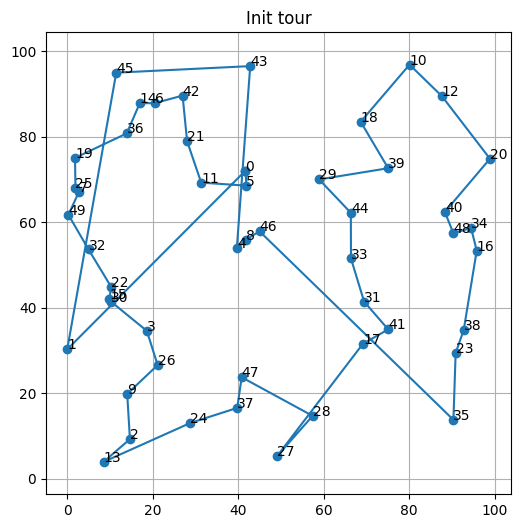

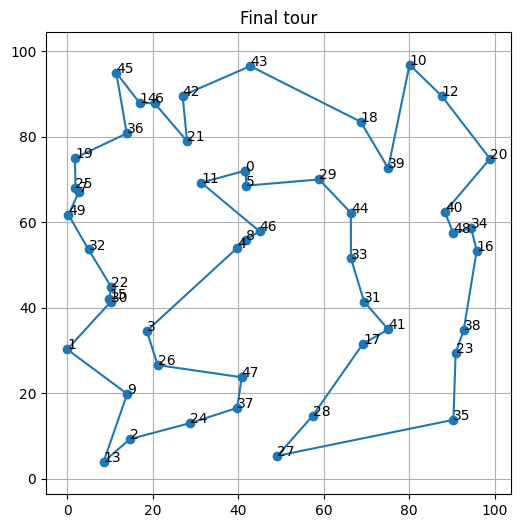

Mode mst finished: base_len=720.348, eval_mean=589.681, best=569.244

Training using bound mode = 1tree
Episode 1/100, total_reward=0.779329, eps=0.3980, tour_len=584.039, gap=17.8521%
Episode 11/100, total_reward=1.218421, eps=0.3785, tour_len=618.106, gap=22.3796%
Episode 21/100, total_reward=1.146441, eps=0.3600, tour_len=593.568, gap=19.1709%
Episode 31/100, total_reward=1.489145, eps=0.3424, tour_len=592.391, gap=19.0103%
Episode 41/100, total_reward=1.302259, eps=0.3257, tour_len=636.574, gap=24.6315%
Episode 51/100, total_reward=1.031689, eps=0.3098, tour_len=569.244, gap=15.7170%
Episode 61/100, total_reward=0.953772, eps=0.2946, tour_len=586.630, gap=18.2149%
Episode 71/100, total_reward=0.761249, eps=0.2802, tour_len=569.244, gap=15.7170%
Episode 81/100, total_reward=0.806023, eps=0.2665, tour_len=569.244, gap=15.7170%
Episode 91/100, total_reward=0.861349, eps=0.2535, tour_len=600.132, gap=20.0549%


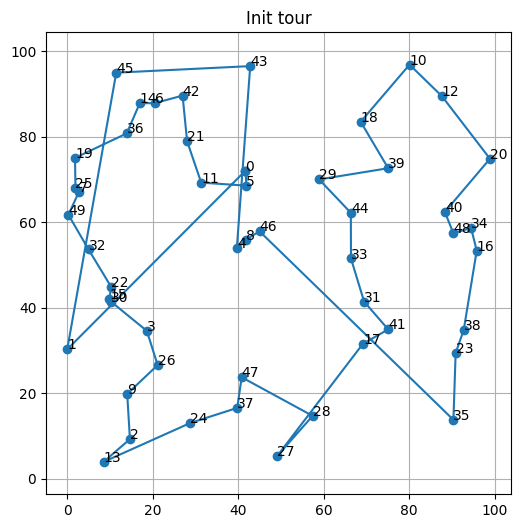

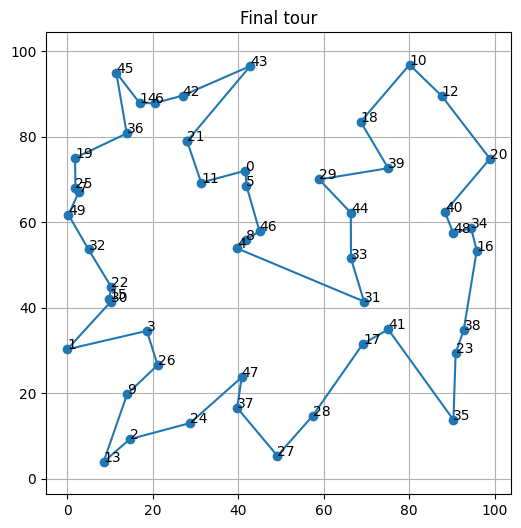

Mode 1tree finished: base_len=720.348, eval_mean=582.425, best=569.244

Summary of bounds and evaluation (None = not run / unavailable):
mst: Lower Bound=476.39
   eval mean=589.681, std=21.021, best=569.244
1tree: Lower Bound=479.78
   eval mean=582.425, std=14.706, best=569.244


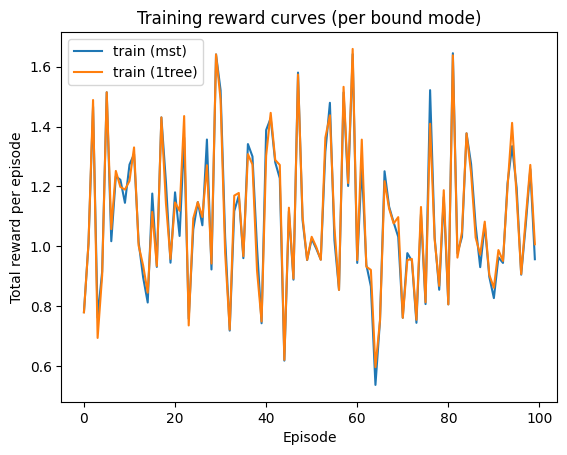

In [ ]:
random.seed(1)
np.random.seed(1)
n_nodes = 50
coords = np.random.rand(n_nodes, 2) * 100
instance = TSPInstance.from_coordinates(f"random_{n_nodes}", coords)
print("External solvers detected:", external_status)
# Feel free to increase nodes, episodes, steps_per_episode for larger experiments
results = demo_compare_bounds(coords, seed=42, episodes=100, steps_per_episode=150, early_stop_gap=0.01, patience=35)

# Plot one training curve (if available)
for mode, r in results.items():
  plt.plot(r["history"], label=f"train ({mode})")
plt.title("Training reward curves (per bound mode)")
plt.xlabel("Episode")
plt.ylabel("Total reward per episode")
plt.legend()
plt.show()

In [ ]:
from python_tsp.exact import solve_tsp_dynamic_programming, solve_tsp_branch_and_bound

n_nodes = 17
coords = np.random.rand(n_nodes, 2) * 100
instance = TSPInstance.from_coordinates(f"random_{n_nodes}", coords)

permutation, distance = solve_tsp_dynamic_programming(instance.distances)
print(permutation)
print(distance)

permutation, distance = solve_tsp_branch_and_bound(instance.distances)
print(permutation)
print(distance)

[0, 7, 5, 8, 9, 13, 14, 12, 15, 4, 6, 11, 3, 10, 16, 2, 1]
358.6336562753109
[0, 7, 5, 8, 9, 13, 14, 12, 15, 4, 6, 11, 3, 10, 16, 2, 1]
358.6336562753109
